In [2]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# Load the data
df = pd.read_csv('/content/Advertising.csv')

In [4]:
# Look at first few rows
print("First 5 rows of data:")
print(df.head())
print("\n")

First 5 rows of data:
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9




In [5]:
# Check if there are any missing values
print("Missing values in each column:")
print(df.isnull().sum())
print("\n")

Missing values in each column:
Unnamed: 0    0
TV            0
Radio         0
Newspaper     0
Sales         0
dtype: int64




In [6]:
# Basic statistics
print("Statistical summary:")
print(df.describe())
print("\n")

Statistical summary:
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std     57.879185   85.854236   14.846809   21.778621    5.217457
min      1.000000    0.700000    0.000000    0.300000    1.600000
25%     50.750000   74.375000    9.975000   12.750000   10.375000
50%    100.500000  149.750000   22.900000   25.750000   12.900000
75%    150.250000  218.825000   36.525000   45.100000   17.400000
max    200.000000  296.400000   49.600000  114.000000   27.000000




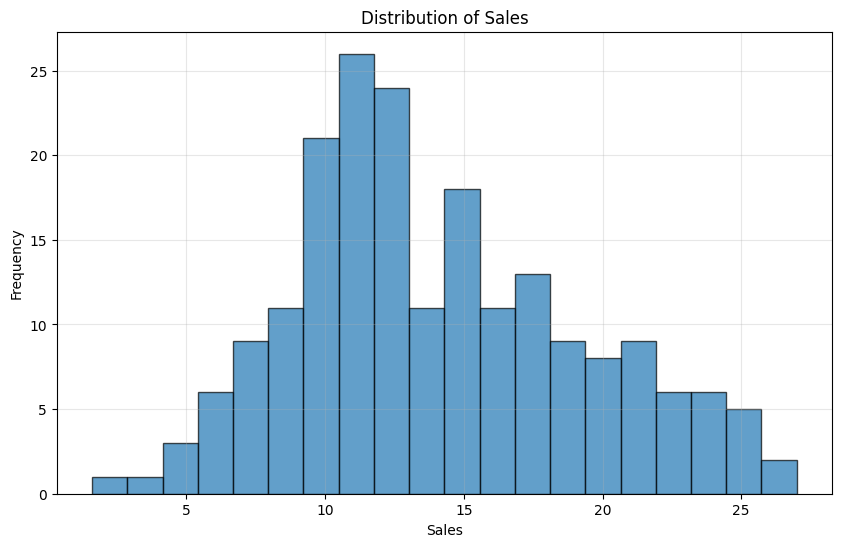

In [7]:
# ============= VISUALIZATION 1: Distribution of Sales =============
plt.figure(figsize=(10, 6))
plt.hist(df['Sales'], bins=20, edgecolor='black', alpha=0.7)
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.title('Distribution of Sales')
plt.grid(True, alpha=0.3)
plt.show()

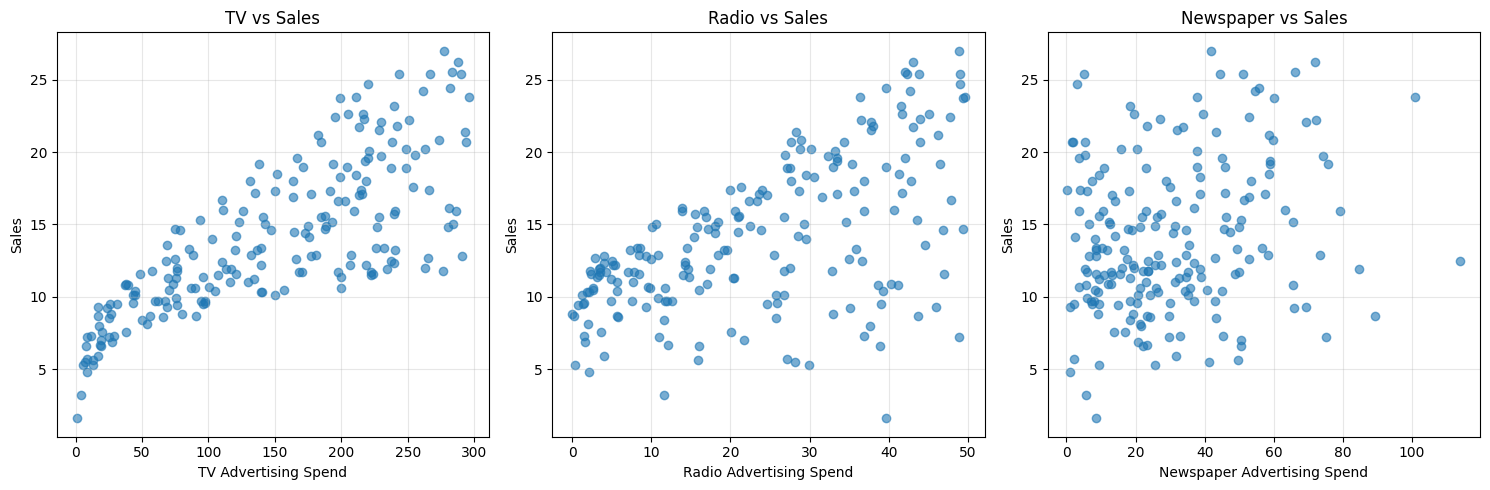

In [8]:
# ============= VISUALIZATION 2: Relationship between each ad type and sales =============
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# TV vs Sales
axes[0].scatter(df['TV'], df['Sales'], alpha=0.6)
axes[0].set_xlabel('TV Advertising Spend')
axes[0].set_ylabel('Sales')
axes[0].set_title('TV vs Sales')
axes[0].grid(True, alpha=0.3)

# Radio vs Sales
axes[1].scatter(df['Radio'], df['Sales'], alpha=0.6)
axes[1].set_xlabel('Radio Advertising Spend')
axes[1].set_ylabel('Sales')
axes[1].set_title('Radio vs Sales')
axes[1].grid(True, alpha=0.3)

# Newspaper vs Sales
axes[2].scatter(df['Newspaper'], df['Sales'], alpha=0.6)
axes[2].set_xlabel('Newspaper Advertising Spend')
axes[2].set_ylabel('Sales')
axes[2].set_title('Newspaper vs Sales')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

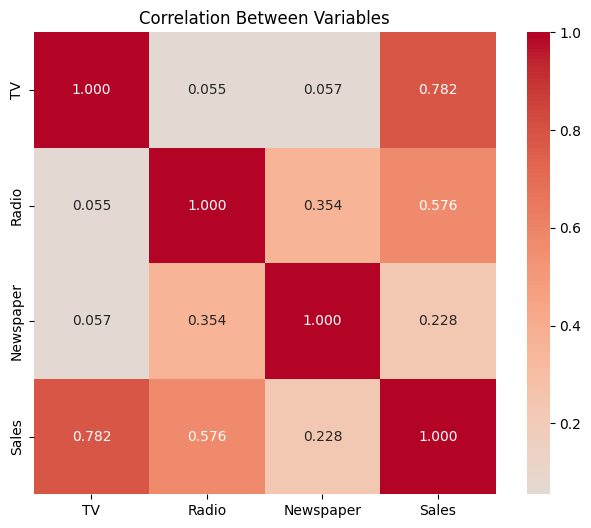

In [9]:
# ============= VISUALIZATION 3: Correlation Heatmap =============
plt.figure(figsize=(8, 6))
correlation = df[['TV', 'Radio', 'Newspaper', 'Sales']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            square=True, fmt='.3f')
plt.title('Correlation Between Variables')
plt.show()

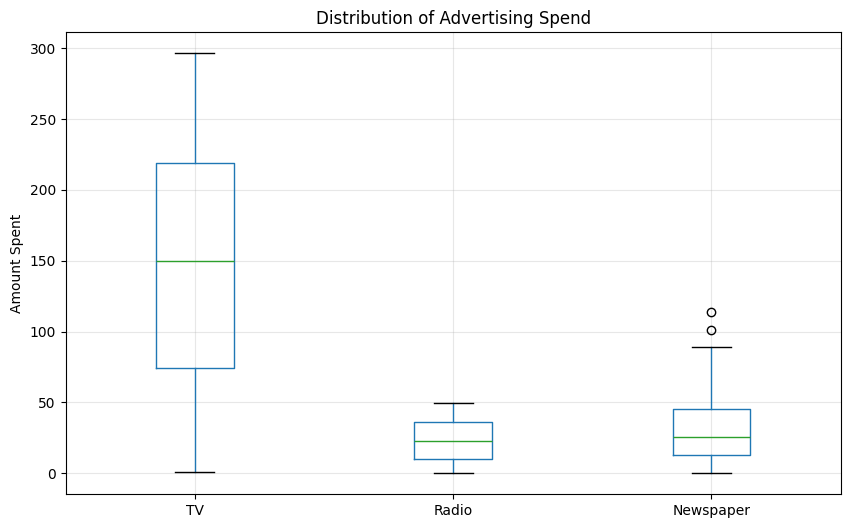

In [10]:
# ============= VISUALIZATION 4: Box plots to see data spread =============
plt.figure(figsize=(10, 6))
df[['TV', 'Radio', 'Newspaper']].boxplot()
plt.title('Distribution of Advertising Spend')
plt.ylabel('Amount Spent')
plt.xticks([1, 2, 3], ['TV', 'Radio', 'Newspaper'])
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# ============= PREPARE DATA FOR MODEL =============
# Features (X) - what we use to predict
X = df[['TV', 'Radio', 'Newspaper']]

# Target (y) - what we want to predict
y = df['Sales']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\n")

Features (X) shape: (200, 3)
Target (y) shape: (200,)




In [12]:
# Split data into training and testing sets
# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data: {X_train.shape[0]} samples")
print(f"Testing data: {X_test.shape[0]} samples")
print("\n")

Training data: 160 samples
Testing data: 40 samples




In [13]:
# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model training completed!")
print("\n")

Model training completed!




In [14]:
# See what the model learned
print("Model coefficients (how much each ad type affects sales):")
print(f"TV coefficient: {model.coef_[0]:.4f}")
print(f"Radio coefficient: {model.coef_[1]:.4f}")
print(f"Newspaper coefficient: {model.coef_[2]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")
print("\n")

Model coefficients (how much each ad type affects sales):
TV coefficient: 0.0447
Radio coefficient: 0.1892
Newspaper coefficient: 0.0028
Intercept: 2.9791




In [15]:
# Formula: Sales = Intercept + (TV × coefficient) + (Radio × coefficient) + (Newspaper × coefficient)
print("The prediction formula is:")
print(f"Sales = {model.intercept_:.2f} + ({model.coef_[0]:.2f} × TV) + ({model.coef_[1]:.2f} × Radio) + ({model.coef_[2]:.2f} × Newspaper)")
print("\n")

The prediction formula is:
Sales = 2.98 + (0.04 × TV) + (0.19 × Radio) + (0.00 × Newspaper)




In [16]:
# ============= EVALUATE THE MODEL =============
# Make predictions on test data
y_pred = model.predict(X_test)

# Calculate performance metrics
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Performance on Test Data:")
print(f"R² Score: {r2:.4f} (0 to 1, higher is better)")
print(f"RMSE: {rmse:.4f} (lower is better)")
print("\n")

Model Performance on Test Data:
R² Score: 0.8994 (0 to 1, higher is better)
RMSE: 1.7816 (lower is better)




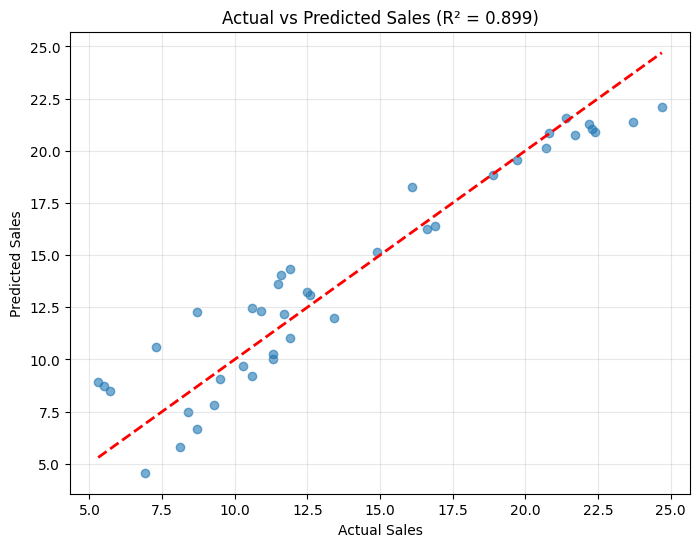

In [17]:
# ============= VISUALIZATION 5: Actual vs Predicted Sales =============
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title(f'Actual vs Predicted Sales (R² = {r2:.3f})')
plt.grid(True, alpha=0.3)
plt.show()

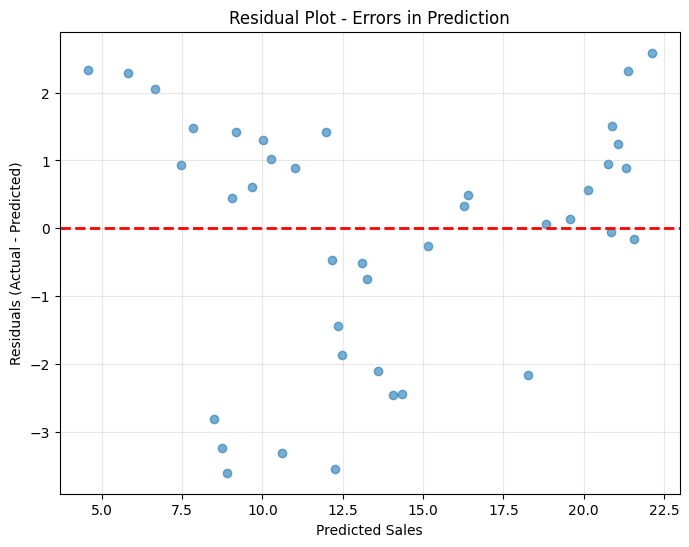

In [18]:
# ============= VISUALIZATION 6: Residuals (errors) =============
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot - Errors in Prediction')
plt.grid(True, alpha=0.3)
plt.show()

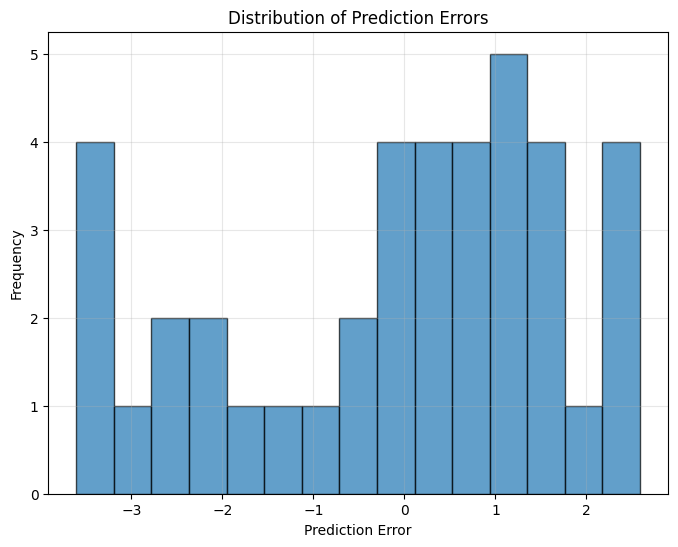

In [19]:
# Histogram of residuals
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=15, edgecolor='black', alpha=0.7)
plt.xlabel('Prediction Error')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')
plt.grid(True, alpha=0.3)
plt.show()

In [20]:
# ============= SIMPLE PREDICTION FUNCTION =============
def predict_sales(tv, radio, newspaper):
    prediction = model.predict([[tv, radio, newspaper]])[0]
    return prediction

In [24]:
# Test the function
print("__Test Prediction__")
print("Example 1: Spend $100 on TV, $20 on Radio, $10 on Newspaper")
sales1 = predict_sales(100, 20, 10)
print(f"Predicted Sales: {sales1:.2f}")

print("\nExample 2: Spend $200 on TV, $30 on Radio, $20 on Newspaper")
sales2 = predict_sales(200, 30, 20)
print(f"Predicted Sales: {sales2:.2f}")

print("\nExample 3: Spend $50 on TV, $10 on Radio, $5 on Newspaper")
sales3 = predict_sales(50, 10, 5)
print(f"Predicted Sales: {sales3:.2f}")

__Test Prediction__
Example 1: Spend $100 on TV, $20 on Radio, $10 on Newspaper
Predicted Sales: 11.26

Example 2: Spend $200 on TV, $30 on Radio, $20 on Newspaper
Predicted Sales: 17.66

Example 3: Spend $50 on TV, $10 on Radio, $5 on Newspaper
Predicted Sales: 7.12


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
